<a href="https://colab.research.google.com/github/priyanka22wh1a1264/week1_datacleaning/blob/main/Task_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analyzing ecommerce sales drop

**company scenario (Flipkart/Amazon):**

we are seeing drop in revenue find the reason and suggest actions

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the datasets

In [ ]:
cus=pd.read_csv("/content/customers.csv")

In [ ]:
ord=pd.read_csv("/content/orders.csv")

In [ ]:
pro=pd.read_csv("/content/products.csv")

In [ ]:
#merging all the datsets
df=pd.merge(cus,ord,on="customer_id",how="inner")
df=pd.merge(df,pro,on="product_id",how="inner")
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000


**EDA**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [ ]:
#converting object date cols into date time format
df["signup_date"]=pd.to_datetime(df["signup_date"])
df["order_date"]=pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    20 non-null     int64         
 1   customer_name  20 non-null     object        
 2   signup_date    20 non-null     datetime64[ns]
 3   order_id       20 non-null     int64         
 4   product_id     20 non-null     int64         
 5   order_date     20 non-null     datetime64[ns]
 6   city           20 non-null     object        
 7   quantity       20 non-null     int64         
 8   product_name   20 non-null     object        
 9   category       20 non-null     object        
 10  price          20 non-null     int64         
dtypes: datetime64[ns](2), int64(5), object(4)
memory usage: 1.8+ KB


In [ ]:
#create a new colname revenue
#formula: revnue=price* quantity
df["revenue"]=df["price"]*df["quantity"]
df

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000
5,103,Amit,2023-12-15,3,203,2024-01-10,Chennai,1,Tablet,Electronics,15000,15000
6,103,Amit,2023-12-15,12,205,2024-05-09,Chennai,1,Watch,Fashion,5000,5000
7,104,Pooja,2024-01-05,5,204,2024-02-18,Bangalore,3,Shoes,Fashion,3000,9000
8,104,Pooja,2024-01-05,13,202,2024-05-15,Bangalore,1,Mobile,Electronics,20000,20000
9,105,Kiran,2024-01-20,6,201,2024-03-05,Chennai,1,Laptop,Electronics,70000,70000


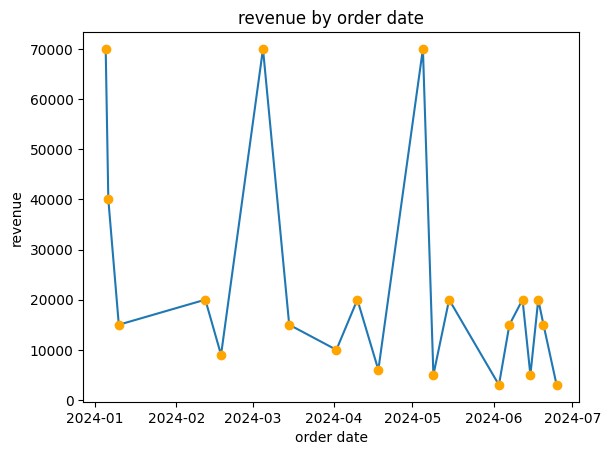

In [ ]:
#revenue trend by order date
revenue=df.groupby("order_date")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
revenue

plt.plot(revenue["order_date"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("order date")
plt.ylabel("revenue")
plt.title("revenue by order date")
plt.show()

the revenue is very less in the last two months(midmay,jun,jul)

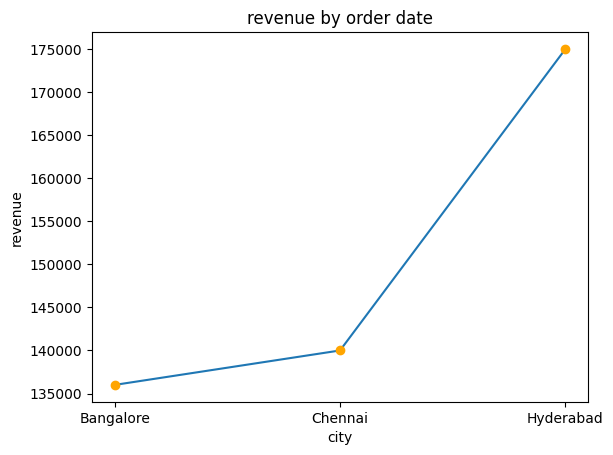

In [ ]:
##revenue trend by city
df["city"].unique()
revenue=df.groupby("city")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
revenue

plt.plot(revenue["city"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("city")
plt.ylabel("revenue")
plt.title("revenue by order date")
plt.show()


**revenue is dropping in banglore**

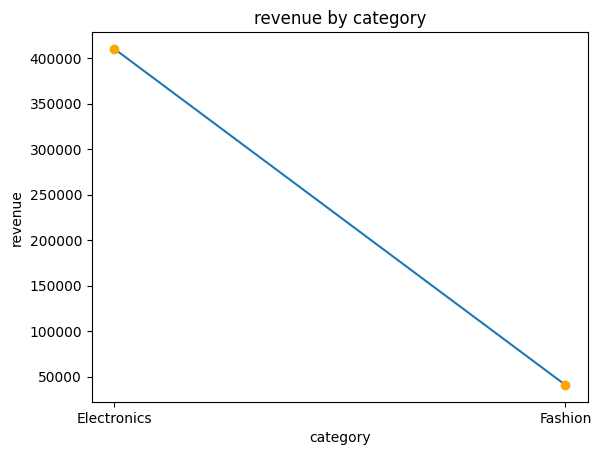

In [ ]:
##revenue trend by category
df["city"].unique()
revenue=df.groupby("category")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
revenue

plt.plot(revenue["category"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("category")
plt.ylabel("revenue")
plt.title("revenue by category")
plt.show()


**in fashion category revenue got dropped**

In [ ]:
#count customers based on order id(count of orders per customer)
df.groupby("customer_id")["order_id"].count()

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


**most of the customers are ordering less**

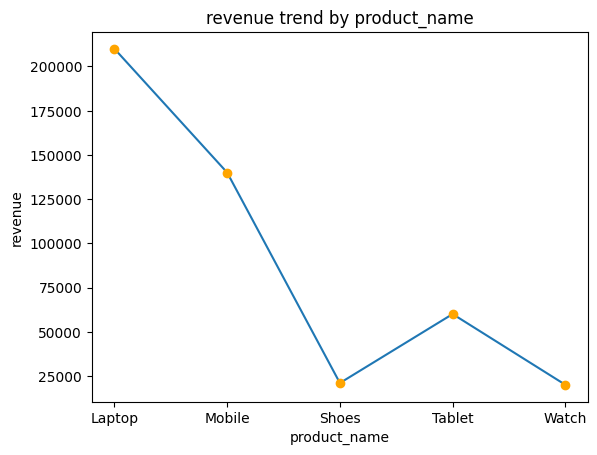

In [ ]:
##revenue trend by productname

revenue=df.groupby("product_name")["revenue"].sum()
revenue=pd.DataFrame(revenue).reset_index()
revenue

plt.plot(revenue["product_name"],revenue["revenue"],marker="o",mfc="orange",mec="orange")
plt.xlabel("product_name")
plt.ylabel("revenue")
plt.title("revenue trend by product_name")
plt.show()

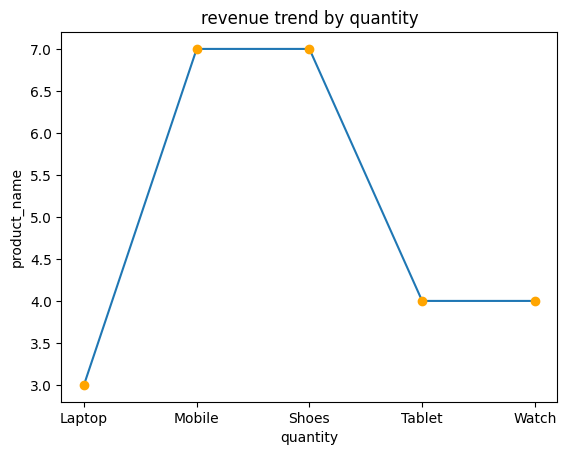

In [ ]:
##revenue trend by productname

revenue=df.groupby("product_name")["quantity"].sum()
revenue=pd.DataFrame(revenue).reset_index()
revenue

plt.plot(revenue["product_name"],revenue["quantity"],marker="o",mfc="orange",mec="orange")
plt.xlabel("quantity")
plt.ylabel("product_name")
plt.title("revenue trend by quantity")
plt.show()

**revenue is very less for shoes and watch**

**Insights :**

1.revenue got dropped in last two months(jun,jul)

2.banglore contributed more in revenue drop

3.fashion category recorded less revenue

4.repeated customers ordered less

5.shoe and watch sales declined significantly

#Recommendations:

1.marketing should be done in banglore

2.provide discounts for shoe and watch

3.coupens ,discounts,loyalty programs for repeated customers

